# Data Understanding
In this stage CRISP-DM, we will explore the datasets to understand their structure, content, and quality. This involves examining the columns, data types, and sample records to get a sense of what information is available. We will also check for missing values, identify any anomalies such as negative numbers or future dates, and generate statistical summaries of key features. By visualizing patterns and spotting anomalies, we try to gain insights into gameplay trends and data quality issues that may impact our analysis in later stages.

For more details on each step, please refer to the Data Understanding documentation at `../docs/1_data_understanding.md`


## Step 1: Import Libraries and Load Dataset
The first step in the data understanding phase is to load the datasets and get a sense of their structure and content. This involves examining the columns, data types, and sample records to understand what information is available and how it can be used for analysis.

1A. Set up project paths and import necessary libraries

In [1]:
# ── Step 1A: Import Libraries ─────────────────────────────────────────────
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.data_loader import DataLoader
from src.utils.anomalies import (
    find_inconsistent_outcomes,
    numeric_anomaly_summary,
)
from src.utils.data_viz_utils import (
    plot_categorical_bottom,
    plot_numeric_box,
)
from src.utils.display_utils import display_side_by_side

1B. Setting up the data directory path

In [2]:
# ── Step 1B: Set up Data Paths ────────────────────────────────────────────
DATA_DIR    = PROJECT_ROOT / "data" / "external"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"

1C. Loading the datasets and displaying them side by side for a quick overview

In [3]:
# ── Step 1C: Load Datasets ────────────────────────────────────────────────
data_loader    = DataLoader(DATA_DIR)
agent_role_df  = data_loader.load_data("agent_master_list.csv")
player_game_df = data_loader.load_data("valorant_games_messy.csv")

display_side_by_side(
    agent_role_df,
    player_game_df,
    titles=["Agent Role", "Player Game"],
    rows=5
)

# Merge to add role column from agent master list
# Using left join to keep all player records, missing agents will have empty role
player_game_df = pd.merge(
    player_game_df, 
    agent_role_df[['Agent', 'Role']], 
    left_on='agent', 
    right_on='Agent', 
    how='left'
)

# Drop redundant Agent column after merge, keep role column
player_game_df = player_game_df.drop(columns=['Agent'])
# Rename Role to role for consistency
player_game_df = player_game_df.rename(columns={'Role': 'role'})

print(f"\nMerged dataset shape: {player_game_df.shape}")
print(f"Added 'role' column. Missing agents will have NaN in role column.")

print("Final Dataset Sample:")
display(player_game_df.head(10).style.background_gradient(cmap='Reds').format(precision=2))

# write data to processed folder for next steps
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
player_game_df.to_csv(INTERIM_DIR / "player_game_data.csv", index=False)
    


Merged dataset shape: (1296, 20)
Added 'role' column. Missing agents will have NaN in role column.
Final Dataset Sample:


,game_id,episode,act,rank,date,agent,map,outcome,round_wins,round_losses,kills,deaths,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag,role
0,1,6,2,Placement,4/11/2023,Cypher,Ascent,Loss,5,13,8,15,4,0.50,-61,3,76,125,3,Sentinel
1,2,6,2,Placement,4/12/2023,Cypher,Icebox,Loss,4,13,3,15,2,0.20,-124,22,42,59,5,Sentinel
2,3,6,2,Placement,4/15/2023,KAY/O,Lotus,Win,13,4,7,12,7,0.60,-46,2,87,132,5,Initiator
3,4,6,2,Placement,4/15/2023,Brimstone,Ascent,Loss,9,13,18,12,10,1.50,23,14,137,230,2,Controller
4,5,6,2,Placement,4/15/2023,Cypher,Haven,Loss,1,13,6,14,3,0.40,-75,7,90,146,4,Sentinel
5,6,6,2,Silver 2,4/15/2023,KAY/O,Haven,Win,13,10,16,15,18,1.10,19,10,155,234,3,Initiator
6,7,6,2,Silver 2,4/15/2023,Cypher,Pearl,Loss,3,13,7,15,5,0.50,-43,11,112,145,4,Sentinel
7,8,6,2,Silver 2,4/15/2023,KAY/O,Icebox,Loss,4,13,8,15,4,0.50,-70,3,73,119,5,Initiator
8,9,6,2,Silver 2,4/16/2023,Cypher,Pearl,Loss,10,13,14,17,4,0.80,-32,9,99,160,4,Sentinel
9,10,6,2,Silver 2,4/16/2023,Phoenix,Fracture,Win,13,4,16,7,6,2.30,111,8,211,284,2,Duelist


## Step 2:
The second step in the Data Understanding phase is to perform Exploratory Data Analysis (EDA) on our Valorant Player datasets. This involves examining the distributions of key variables such as agents, maps, ranks, and performance statistics, as well as identifying missing values, negative numbers, future dates, or unknown agents. By visualizing patterns, spotting anomalies, and understanding relationships between features like agent choice, map, and match outcomes, EDA provides insights into gameplay trends and data quality issues.

2A.  Inspect Data Structure and Samples : Examine the shape, columns and data types to understand what information is available.

In [4]:
# ── Step 2A: Inspect Data Structure ──────────────────────────────────────
# Displaying the shape of the DataFrames to understand the number of records and features
print("Agent Role DataFrame shape:", agent_role_df.shape)
print("Player Game DataFrame shape:", player_game_df.shape)

print("Data Description: \n")
display(player_game_df.describe().style.background_gradient(cmap='Reds').format(precision=2))



Agent Role DataFrame shape: (26, 2)
Player Game DataFrame shape: (1296, 20)
Data Description: 



,game_id,episode,act,round_wins,round_losses,kills,deaths,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag
count,1296.00,1296.00,1296.00,1296.00,1296.00,1296.00,1296.00,1296.00,1296.00,1296.00,1296.00,1296.00,1296.00,1296.00
mean,734.48,7.49,2.06,9.70,9.58,13.65,12.95,4.79,1.14,7.16,29.93,132.53,192.07,3.45
std,518.69,1.10,0.86,4.26,4.31,6.44,5.20,2.78,0.71,41.03,21.22,46.71,68.82,2.09
min,1.00,6.00,1.00,-2.00,-2.00,-3.00,-3.00,0.00,-0.50,-124.00,0.00,0.00,0.00,0.00
25%,324.75,7.00,1.00,7.00,6.00,10.00,10.00,3.00,0.78,-22.00,16.00,104.75,152.00,2.00
50%,648.50,7.00,2.00,11.00,11.00,14.00,14.00,4.00,1.10,6.00,24.00,133.00,195.00,3.00
75%,972.25,9.00,3.00,13.00,13.00,18.00,16.00,6.00,1.50,34.00,35.00,161.00,236.25,5.00
max,1999.00,9.00,3.00,18.00,20.00,35.00,26.00,20.00,9.70,293.00,100.00,373.00,572.00,10.00


2B.  Identify Missing Values : Check for any missing values in the datasets and understand their potential impact on analysis.

In [5]:
# ── Step 2B: Identify Missing Values ─────────────────────────────────────
# Calculating the number of missing values in each column of the player_game_df DataFrame
# Reason: if there are missing values, it can affect the analysis and may require imputation of records, we wont be dropping any records as we want to preserve as much data as possible.
missing_counts = player_game_df.isnull().sum()
missing_percent = (missing_counts / len(player_game_df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing_counts, "Missing %": missing_percent})
missing_df = missing_df[missing_df["Missing Count"] > 0]

print("Missing values per column:")
display(missing_df)


Missing values per column:


,Missing Count,Missing %
rank,15,1.16
outcome,102,7.87
role,25,1.93


Step 2C: Detect Invalid or Anomalous Values: Check for any negative numbers, future dates, or unknown agents that may indicate data quality issues.

In [6]:
# ── Step 2C: Detect Anomalous Values (Numeric) ────────────────────────────
# Detect columns
numeric_cols = player_game_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numeric columns:", numeric_cols)


# Dropdowns
dropdown_numeric = widgets.Dropdown(
    options=numeric_cols,
    description='Numeric Feature:',
    value=numeric_cols[0],
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

#visualize
widgets.interact(plot_numeric_box, df=widgets.fixed(player_game_df), col=dropdown_numeric)


print("Obbservations:")
print("game_id : not an important feature for analysis, can be dropped in future steps")
print("episode : distribution is starting from episode 7 until epiode 9, which is expected as the data was collected during that time period")
print("act : distribution is starting from act 1 until act 3, which is expected as the data was collected during that time period")
print("rounds_win : there are some negative values in the rounds_win column, which is not possible in the context of the game.Although there are high values nearly 18 rounds which is possible but we will need to investigate those records further to understand if they are valid or if they are data entry errors.")
print("round_loss : there are some negative values in the rounds_loss column, which is not possible in the context of the game. Although there are high values nearly 20 rounds which is possible but we will need to investigate those records further to understand if they are valid or if they are data entry errors.")
print("kills : there are some negative values in the kills column, which is not possible in the context of the game. Although there are high values nearly 35 kills which is possible")
print("assists : its not an important feature for analysis, can be dropped in future steps")
print("kdr : Some negative values in the kdr column, which is not possible in the context of the game")
print("avg_dmg_delta : There are some negative values which are not possible in the context of the game, but positive values are quite high but cant be verified as these calcualtions are not available in public domain")
print("headshot% : The range of headshot% is between 0 and 100, which is expected. ")
print("avg)dmg : There are some negative values which are not possible in the context of the game, but positive values are quite high but cant be verified as these calcualtions are not available in public domain")
print("acs : There are some negative values which are not possible in the context of the game, but positive values are quite high but cant be verified as these calcualtions are not available in public domain")
print("num_frag : this is correct as it is a count of the number of times a player was the first to get a kill in a round, which can be zero or more.")

Numeric columns: ['game_id', 'episode', 'act', 'round_wins', 'round_losses', 'kills', 'deaths', 'assists', 'kdr', 'avg_dmg_delta', 'headshot_pct', 'avg_dmg', 'acs', 'num_frag']


interactive(children=(Dropdown(description='Numeric Feature:', layout=Layout(width='50%'), options=('game_id',…

Obbservations:
game_id : not an important feature for analysis, can be dropped in future steps
episode : distribution is starting from episode 7 until epiode 9, which is expected as the data was collected during that time period
act : distribution is starting from act 1 until act 3, which is expected as the data was collected during that time period
rounds_win : there are some negative values in the rounds_win column, which is not possible in the context of the game.Although there are high values nearly 18 rounds which is possible but we will need to investigate those records further to understand if they are valid or if they are data entry errors.
round_loss : there are some negative values in the rounds_loss column, which is not possible in the context of the game. Although there are high values nearly 20 rounds which is possible but we will need to investigate those records further to understand if they are valid or if they are data entry errors.
kills : there are some negative valu

In [7]:



# ── Step 2C: Detect Anomalous Values (Categorical) ───────────────────────
# For categorical columns, we include both 'object' and 'string' data types to capture all potential categorical features.
# Exclude date columns - they will be type cast to datetime separately.
categorical_cols = [col for col in player_game_df.select_dtypes(include=['object', 'string']).columns.tolist()
                    if 'date' not in col.lower()]

# Create dropdown for categorical features
dropdown_cat = widgets.Dropdown(
    options=categorical_cols,
    description='Categorical/Date Feature:',
    value=categorical_cols[0],
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

#visualize
widgets.interact(plot_categorical_bottom, df=widgets.fixed(player_game_df), col=dropdown_cat, bottom_n=(20,1000,100))

interactive(children=(Dropdown(description='Categorical/Date Feature:', layout=Layout(width='50%'), options=('…

<function src.utils.data_viz_utils.plot_categorical_bottom(df: pandas.core.frame.DataFrame, col: str, bottom_n=10)>

Step 2C: Statistical Summaries of Key Features: Generate descriptive statistics for numeric features and frequency counts for categorical features to understand central tendencies, variability, and common categories.

In [8]:
# ── Step 2C: Statistical Summaries: Match Outcome Anomalies ─────────────
print("Match Outcome Anomalies:")
# if there are any records where the match outcome is inconsistent with the expected outcome based on the player's performance metrics, it could indicate data entry errors or anomalies in the dataset. This can help identify potential issues with the data quality and ensure that the analysis is based on accurate and reliable information.
inconsistent_outcome = find_inconsistent_outcomes(player_game_df)
display(inconsistent_outcome)

Match Outcome Anomalies:


,game_id,episode,act,rank,date,agent,map,outcome,round_wins,round_losses,kills,deaths,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag,role
26,27,6,2,Gold 1,4/22/2023,Cypher,Split,Draw,15,15,35,21,8,1.7,68,13,200,324,1,Sentinel
76,77,6,3,Gold 3,5/9/2023,Cypher,Bind,Draw,15,15,17,19,9,0.9,-2,19,115,173,4,Sentinel
92,93,6,3,Gold 3,5/18/2023,Cypher,Split,Draw,15,15,24,21,9,1.1,6,12,144,223,1,Sentinel
127,128,6,3,Platinum 1,5/23/2023,Cypher,Lotus,Draw,14,14,25,17,4,1.5,35,13,152,243,1,Sentinel
307,308,7,1,Platinum 3,7/23/2023,Cypher,Bind,Draw,14,14,16,20,6,0.8,-37,13,100,154,5,Sentinel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,1740,6,2,Diamond 2,11/11/2024,Brimstone,Breeze,Draw,6,8,-2,7,10,1.0,17,77,13,266,7,Controller
1292,1010,7,1,Platinum 1,3/11/2024,Omen,Sunset,Draw,15,3,-2,13,5,-0.2,38,1,206,68,9,Controller
1293,1495,6,2,Diamond 2,5/30/2023,Fade,Breeze,Unknown,2,12,17,14,6,0.7,-25,80,133,100,3,Initiator
1294,1125,9,2,Platinum 1,5/4/2023,Viper,Lotus,NaN,7,3,6,13,10,0.8,-30,52,73,216,4,Controller


In [9]:
# ── Step 2C: Statistical Summaries : Numeric Anomalies ───────────────────
# Check for numeric anomalies in key performance metrics such as kills, deaths, round wins, round losses, and KDR.The values shouldn't be negative and should be within a reasonable range based on typical player performance. Identifying any outliers or unrealistic values can help ensure the integrity of the dataset and improve the accuracy of any subsequent analysis or modeling.
numeric_summary = numeric_anomaly_summary(
    player_game_df,
    ['kills','deaths','round_wins','round_losses','kdr']
)
print("Numeric Anomalies Summary:")
display(numeric_summary)

Numeric Anomalies Summary:


,Feature,Negative Values,Zero Values,Outliers (>3σ)
0,kills,42,8,5
1,deaths,41,8,16
2,round_wins,42,15,0
3,round_losses,32,15,0
4,kdr,43,9,10


## Step 2D: Label Encoding : Rank, Agent, Map

In [10]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['rank', 'agent', 'map']
le = LabelEncoder()

df_label_encoded = player_game_df.copy()
label_mappings = {}

for col in label_cols:
    df_label_encoded[col] = le.fit_transform(player_game_df[col].astype(str))
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("Label Encoding Mappings:\n")
for col, mapping in label_mappings.items():
    print(f"  {col}: {mapping}\n")

df_label_encoded[['rank', 'agent', 'map']].head(10)


Label Encoding Mappings:

  rank: {'Ascendant 1': np.int64(0), 'Ascendant 2': np.int64(1), 'Diamond 1': np.int64(2), 'Diamond 2': np.int64(3), 'Diamond 3': np.int64(4), 'Gold 1': np.int64(5), 'Gold 2': np.int64(6), 'Gold 3': np.int64(7), 'Placement': np.int64(8), 'Platinum 1': np.int64(9), 'Platinum 2': np.int64(10), 'Platinum 3': np.int64(11), 'Silver 2': np.int64(12), 'Silver 3': np.int64(13), 'nan': np.int64(14)}

  agent: {'Astra': np.int64(0), 'Breach': np.int64(1), 'Brimstone': np.int64(2), 'Cypher': np.int64(3), 'Fade': np.int64(4), 'KAY/O': np.int64(5), 'Killjoy': np.int64(6), 'Omen': np.int64(7), 'Phoenix': np.int64(8), 'UnknownAgent': np.int64(9), 'Viper': np.int64(10), 'Vyse': np.int64(11)}

  map: {'Abyss': np.int64(0), 'Ascent': np.int64(1), 'Bind': np.int64(2), 'Breeze': np.int64(3), 'Fracture': np.int64(4), 'Haven': np.int64(5), 'Icebox': np.int64(6), 'Lotus': np.int64(7), 'Pearl': np.int64(8), 'Split': np.int64(9), 'Sunset': np.int64(10)}



,rank,agent,map
0,8,3,1
1,8,3,6
2,8,5,7
3,8,2,1
4,8,3,5
5,12,5,5
6,12,3,8
7,12,5,6
8,12,3,8
9,12,8,4


Correlation Matrix with All Features (Numeric & Label/One-Hot-Categorical):
                 game_id  episode   act  rank  agent   map  round_wins  \
game_id             1.00     0.39 -0.08 -0.12   0.29 -0.05       -0.30   
episode             0.39     1.00 -0.30 -0.46   0.13 -0.05       -0.03   
act                -0.08    -0.30  1.00 -0.04  -0.06 -0.00       -0.02   
rank               -0.12    -0.46 -0.04  1.00  -0.03  0.05       -0.06   
agent               0.29     0.13 -0.06 -0.03   1.00  0.03       -0.14   
map                -0.05    -0.05 -0.00  0.05   0.03  1.00        0.01   
round_wins         -0.30    -0.03 -0.02 -0.06  -0.14  0.01        1.00   
round_losses       -0.31    -0.00  0.03 -0.09  -0.06 -0.02       -0.06   
kills              -0.38    -0.02  0.00 -0.07  -0.12  0.02        0.40   
deaths             -0.39     0.00  0.01 -0.04  -0.06  0.02        0.12   
assists             0.03    -0.07  0.06  0.11  -0.04 -0.01        0.19   
kdr                -0.06    -0.03  0

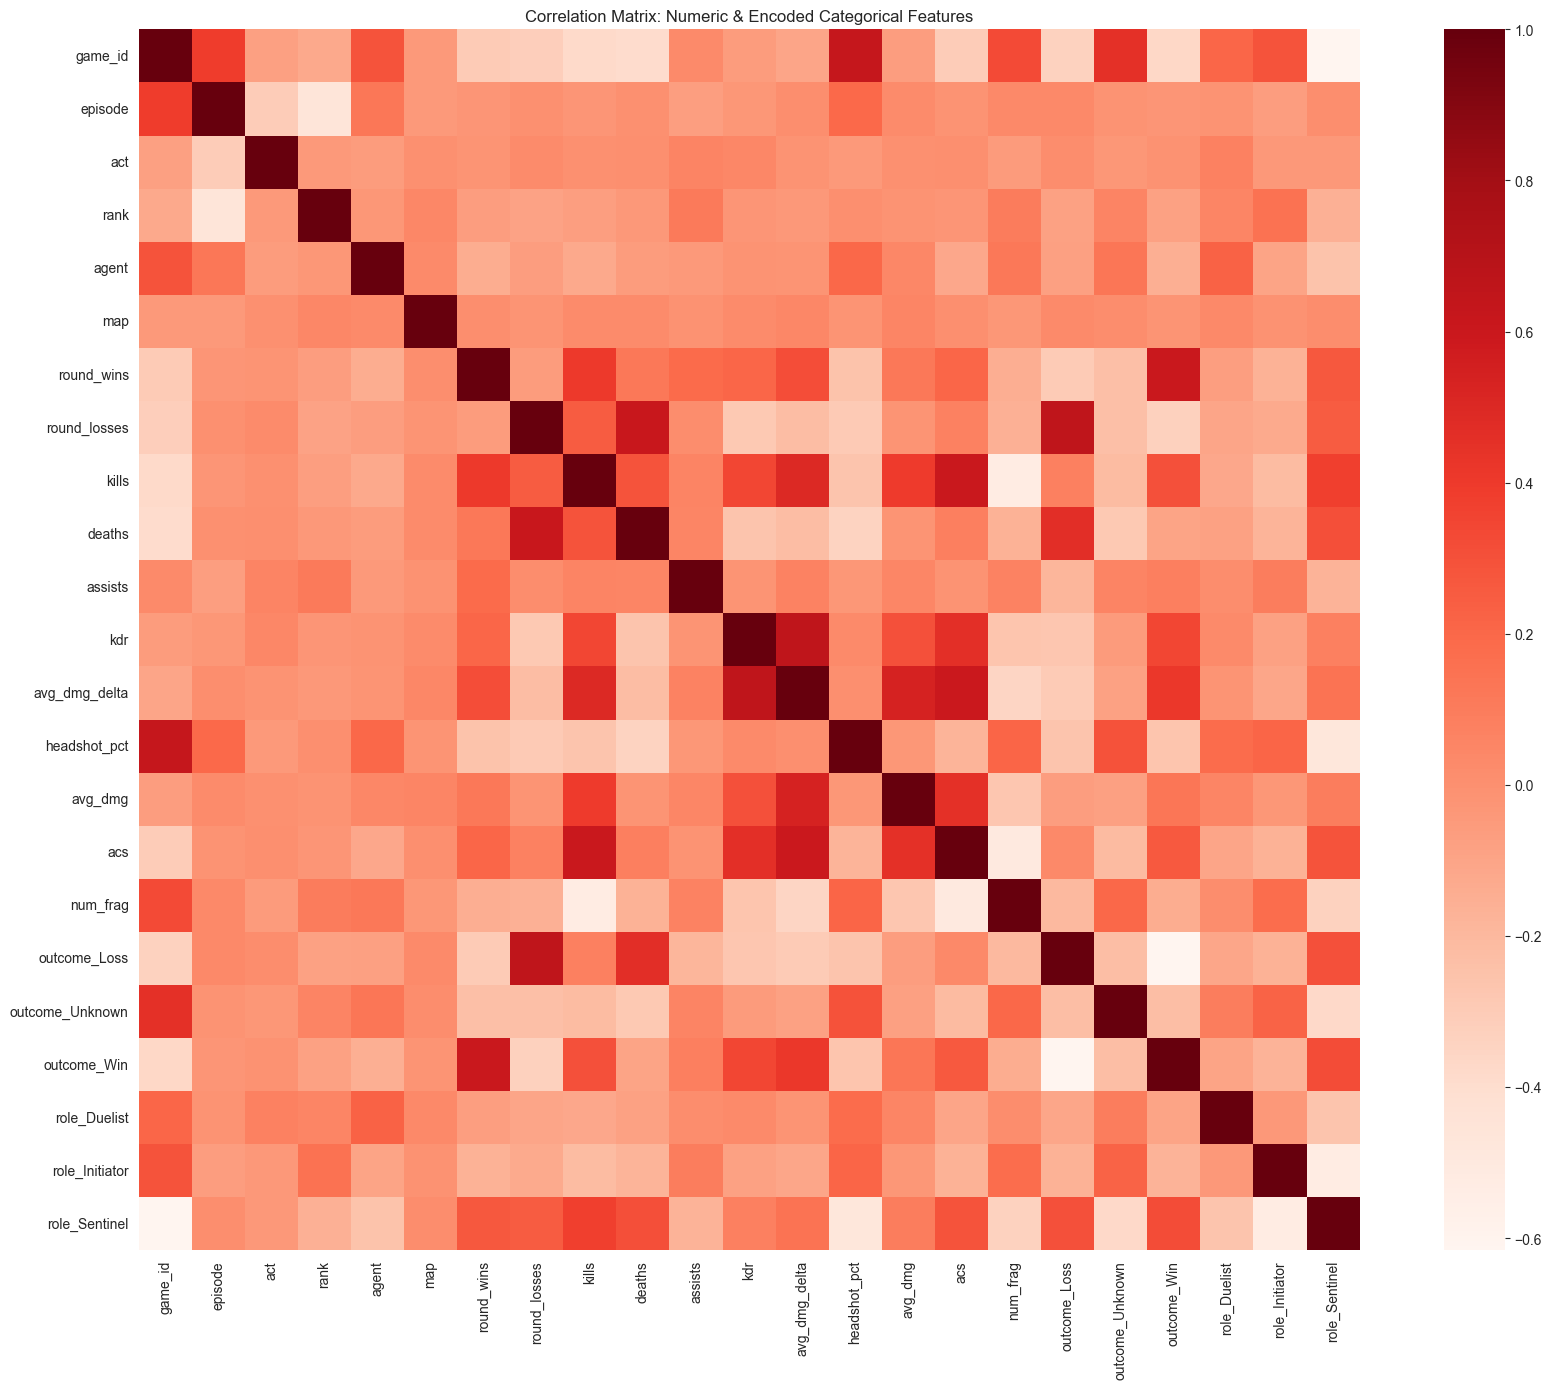

In [11]:
# ── Step 2E: Statistical Summaries : Correlation Analysis ─────────────────
categorical_features = ['outcome', 'role']

# Drop date columns : they cannot be one-hot encoded or correlated numerically
date_cols = [col for col in df_label_encoded.columns if 'date' in col.lower()]
df_for_corr = df_label_encoded.drop(columns=date_cols)

# rank, agent, map are already label-encoded; one-hot encode remaining categoricals
df_encoded = pd.get_dummies(df_for_corr, columns=categorical_features, drop_first=True)

print("Correlation Matrix with All Features (Numeric & Label/One-Hot-Categorical):")
corr_matrix = df_encoded.corr()
print(corr_matrix.round(2)) 
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='Reds', annot=False, square=True)
plt.title("Correlation Matrix: Numeric & Encoded Categorical Features")
plt.tight_layout()
plt.show()
